# 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

FINAL   = r"C:\Users\alokhande\Desktop\Project_Daedalus\data\final"
CHARTS  = r"C:\Users\alokhande\Desktop\Project_Daedalus\outputs\charts"

df = pd.read_csv(os.path.join(FINAL, "daedalus_scored.csv"))

# visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

print(f"Loaded: {df.shape}")
print(df.columns.tolist())

Loaded: (359, 33)
['city', 'aqi_value', 'aqi_category', 'pm2.5_aqi_value', 'meal_cheap_usd', 'meal_midrange_usd', 'rent_1br_outside_usd', 'rent_3br_city_usd', 'basic_utilities_usd', 'monthly_pass_usd', 'avg_net_salary_usd', 'popcity', 'densitycity', 'congestion2019', 'crime_index', 'safety_index', 'aqi_score', 'pm25_score', 'air_quality_score', 'cost_index_raw', 'cost_score_absolute', 'monthly_living_cost', 'affordability_ratio', 'cost_score_affordability', 'safety_score', 'density_score_raw', 'congestion_score', 'urban_score', 'livability_score_absolute', 'livability_score_affordability', 'rank_absolute', 'rank_affordability', 'country']


# 2. Pillar score distributions:

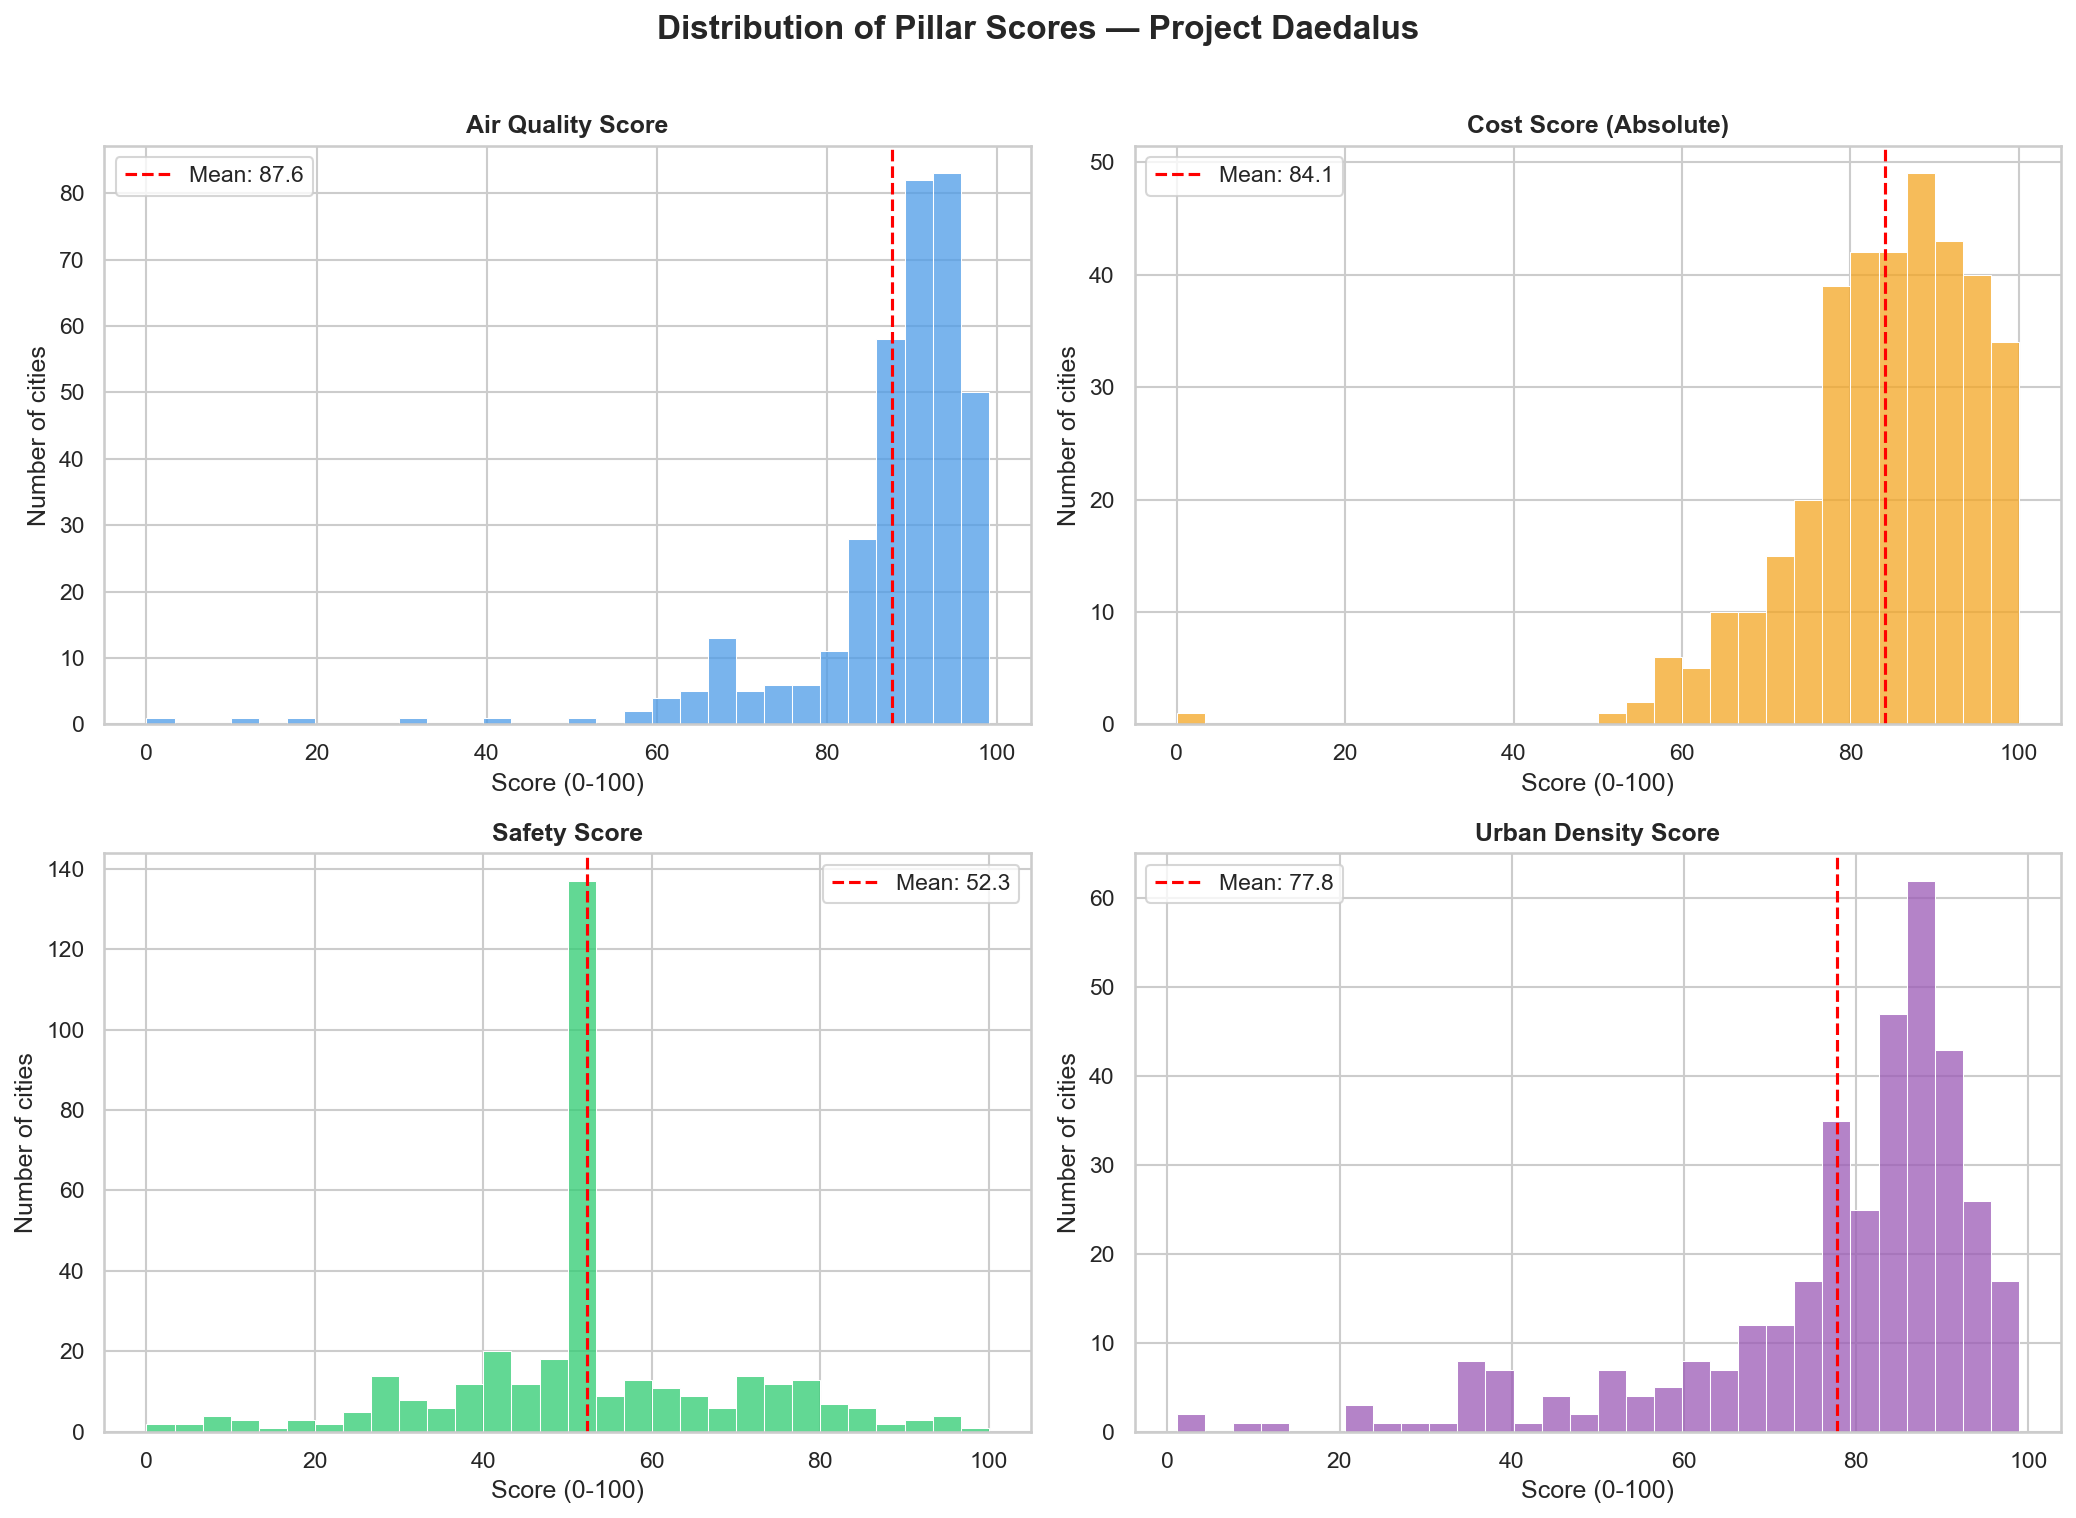

Saved → 01_pillar_distributions.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Pillar Scores — Project Daedalus", 
             fontsize=16, fontweight='bold', y=1.01)

pillars = [
    ('air_quality_score', 'Air Quality Score',  '#4C9BE8'),
    ('cost_score_absolute', 'Cost Score (Absolute)', '#F4A623'),
    ('safety_score',      'Safety Score',        '#2ECC71'),
    ('urban_score',       'Urban Density Score', '#9B59B6'),
]

for ax, (col, title, color) in zip(axes.flatten(), pillars):
    sns.histplot(df[col], bins=30, ax=ax, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score (0-100)')
    ax.set_ylabel('Number of cities')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS, "01_pillar_distributions.png"), bbox_inches='tight')
plt.show()
print("Saved → 01_pillar_distributions.png")

# 3. Correlation Heatmap

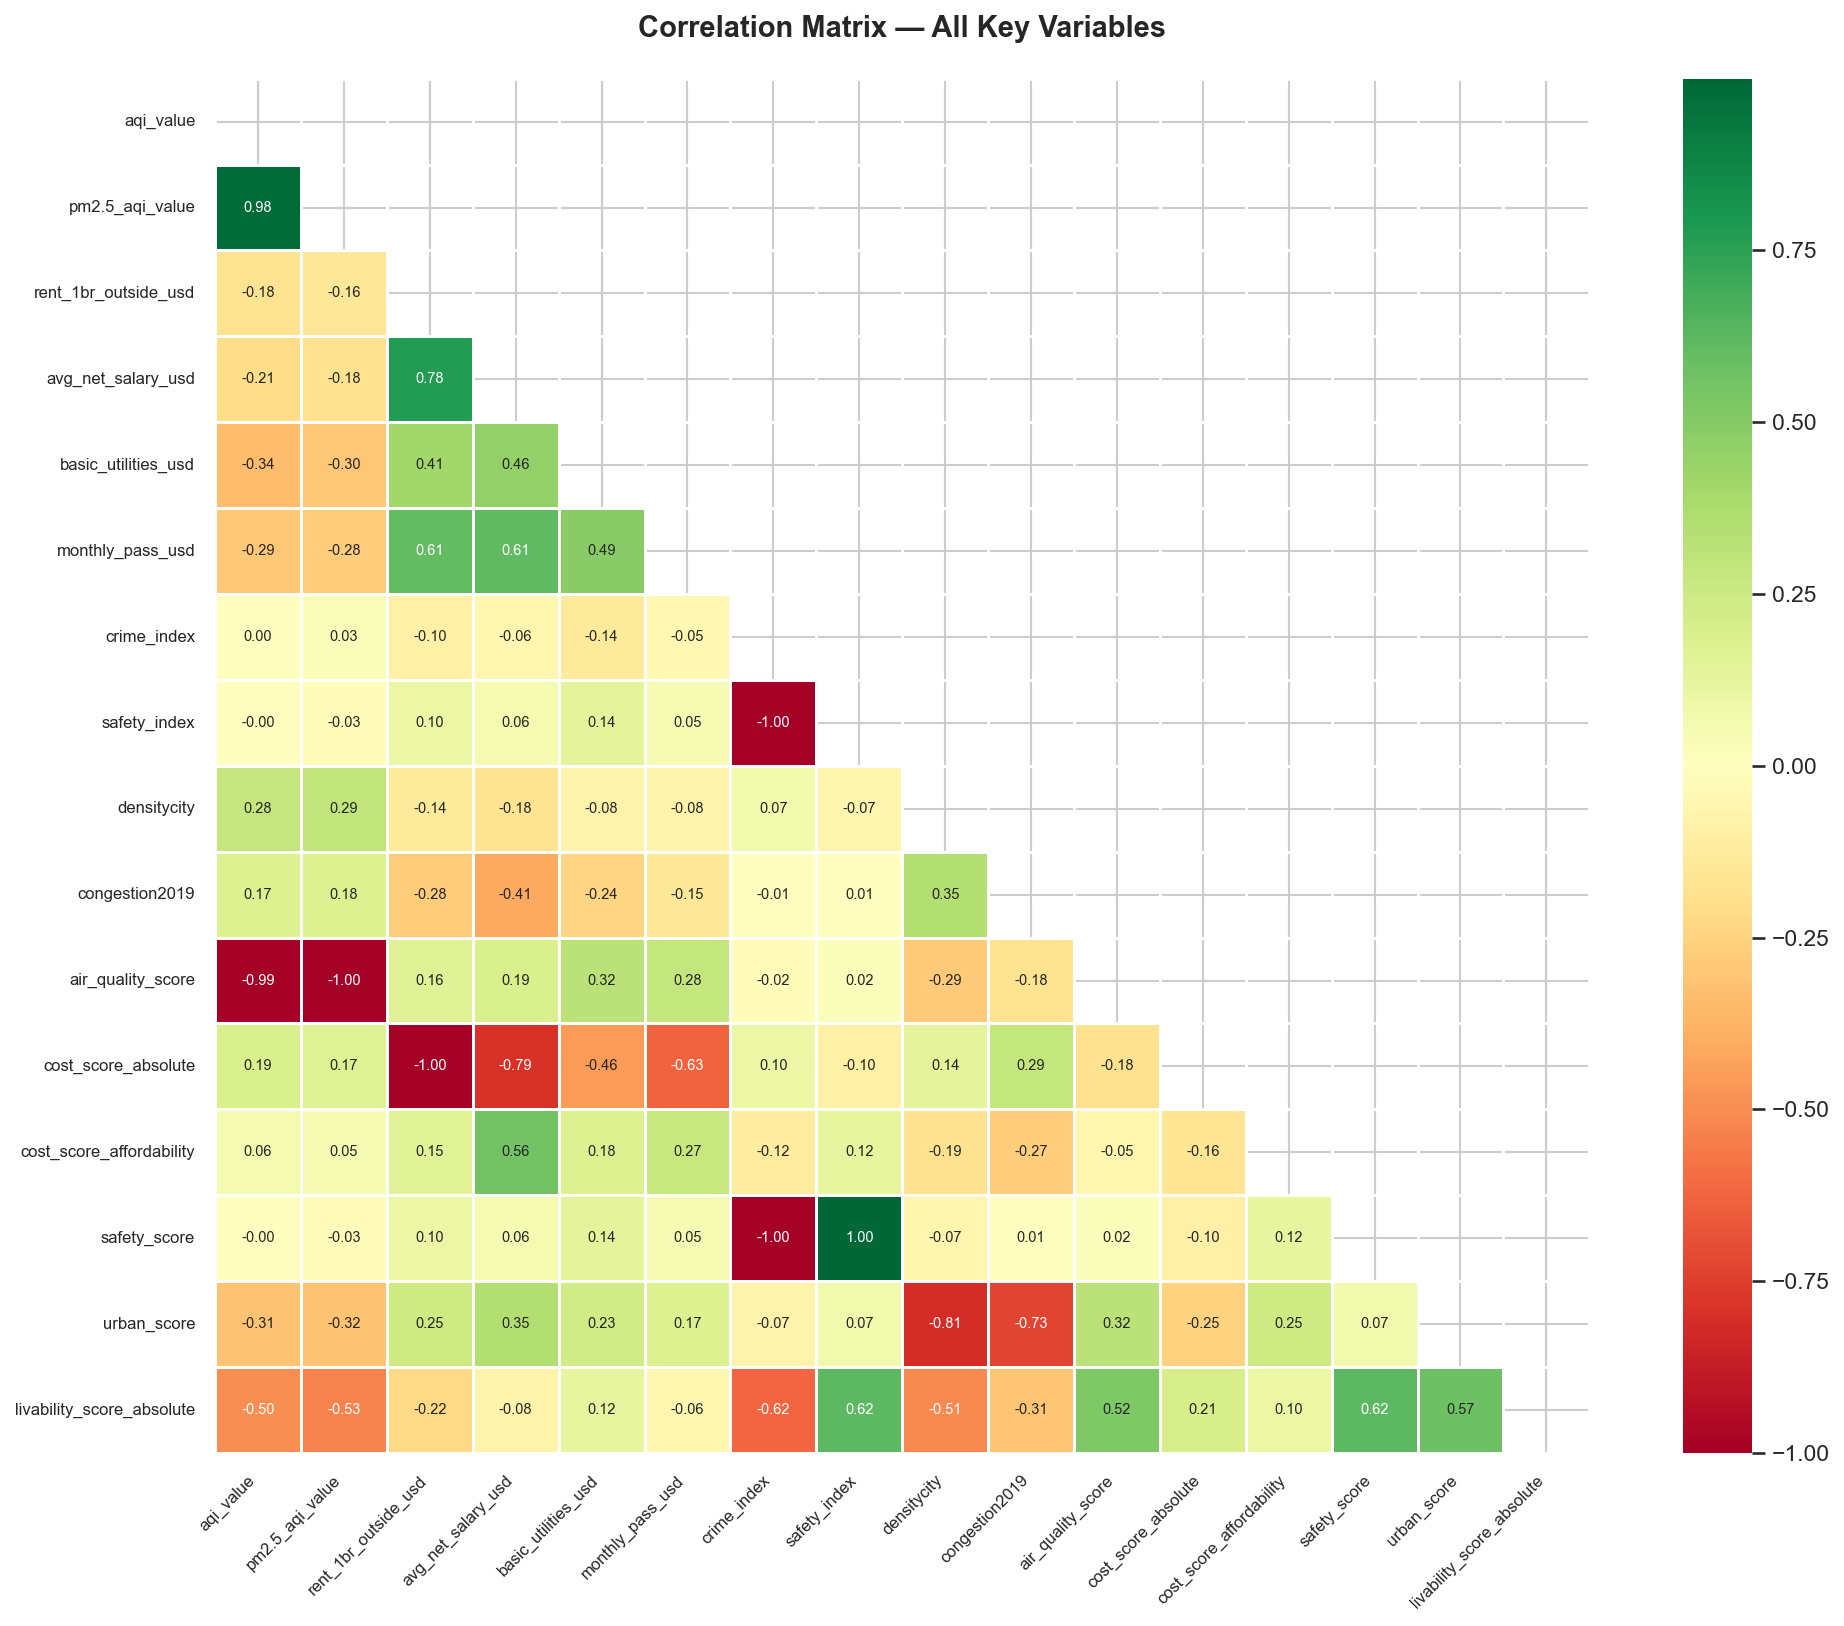

Saved → 02_correlation_heatmap.png


In [3]:
corr_cols = [
    'aqi_value', 'pm2.5_aqi_value',
    'rent_1br_outside_usd', 'avg_net_salary_usd',
    'basic_utilities_usd', 'monthly_pass_usd',
    'crime_index', 'safety_index',
    'densitycity', 'congestion2019',
    'air_quality_score', 'cost_score_absolute',
    'cost_score_affordability', 'safety_score',
    'urban_score', 'livability_score_absolute'
]

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)

ax.set_title("Correlation Matrix — All Key Variables", 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS, "02_correlation_heatmap.png"), bbox_inches='tight')
plt.show()
print("Saved → 02_correlation_heatmap.png")

# 4. Top 20 and Bottom 20 Cities:

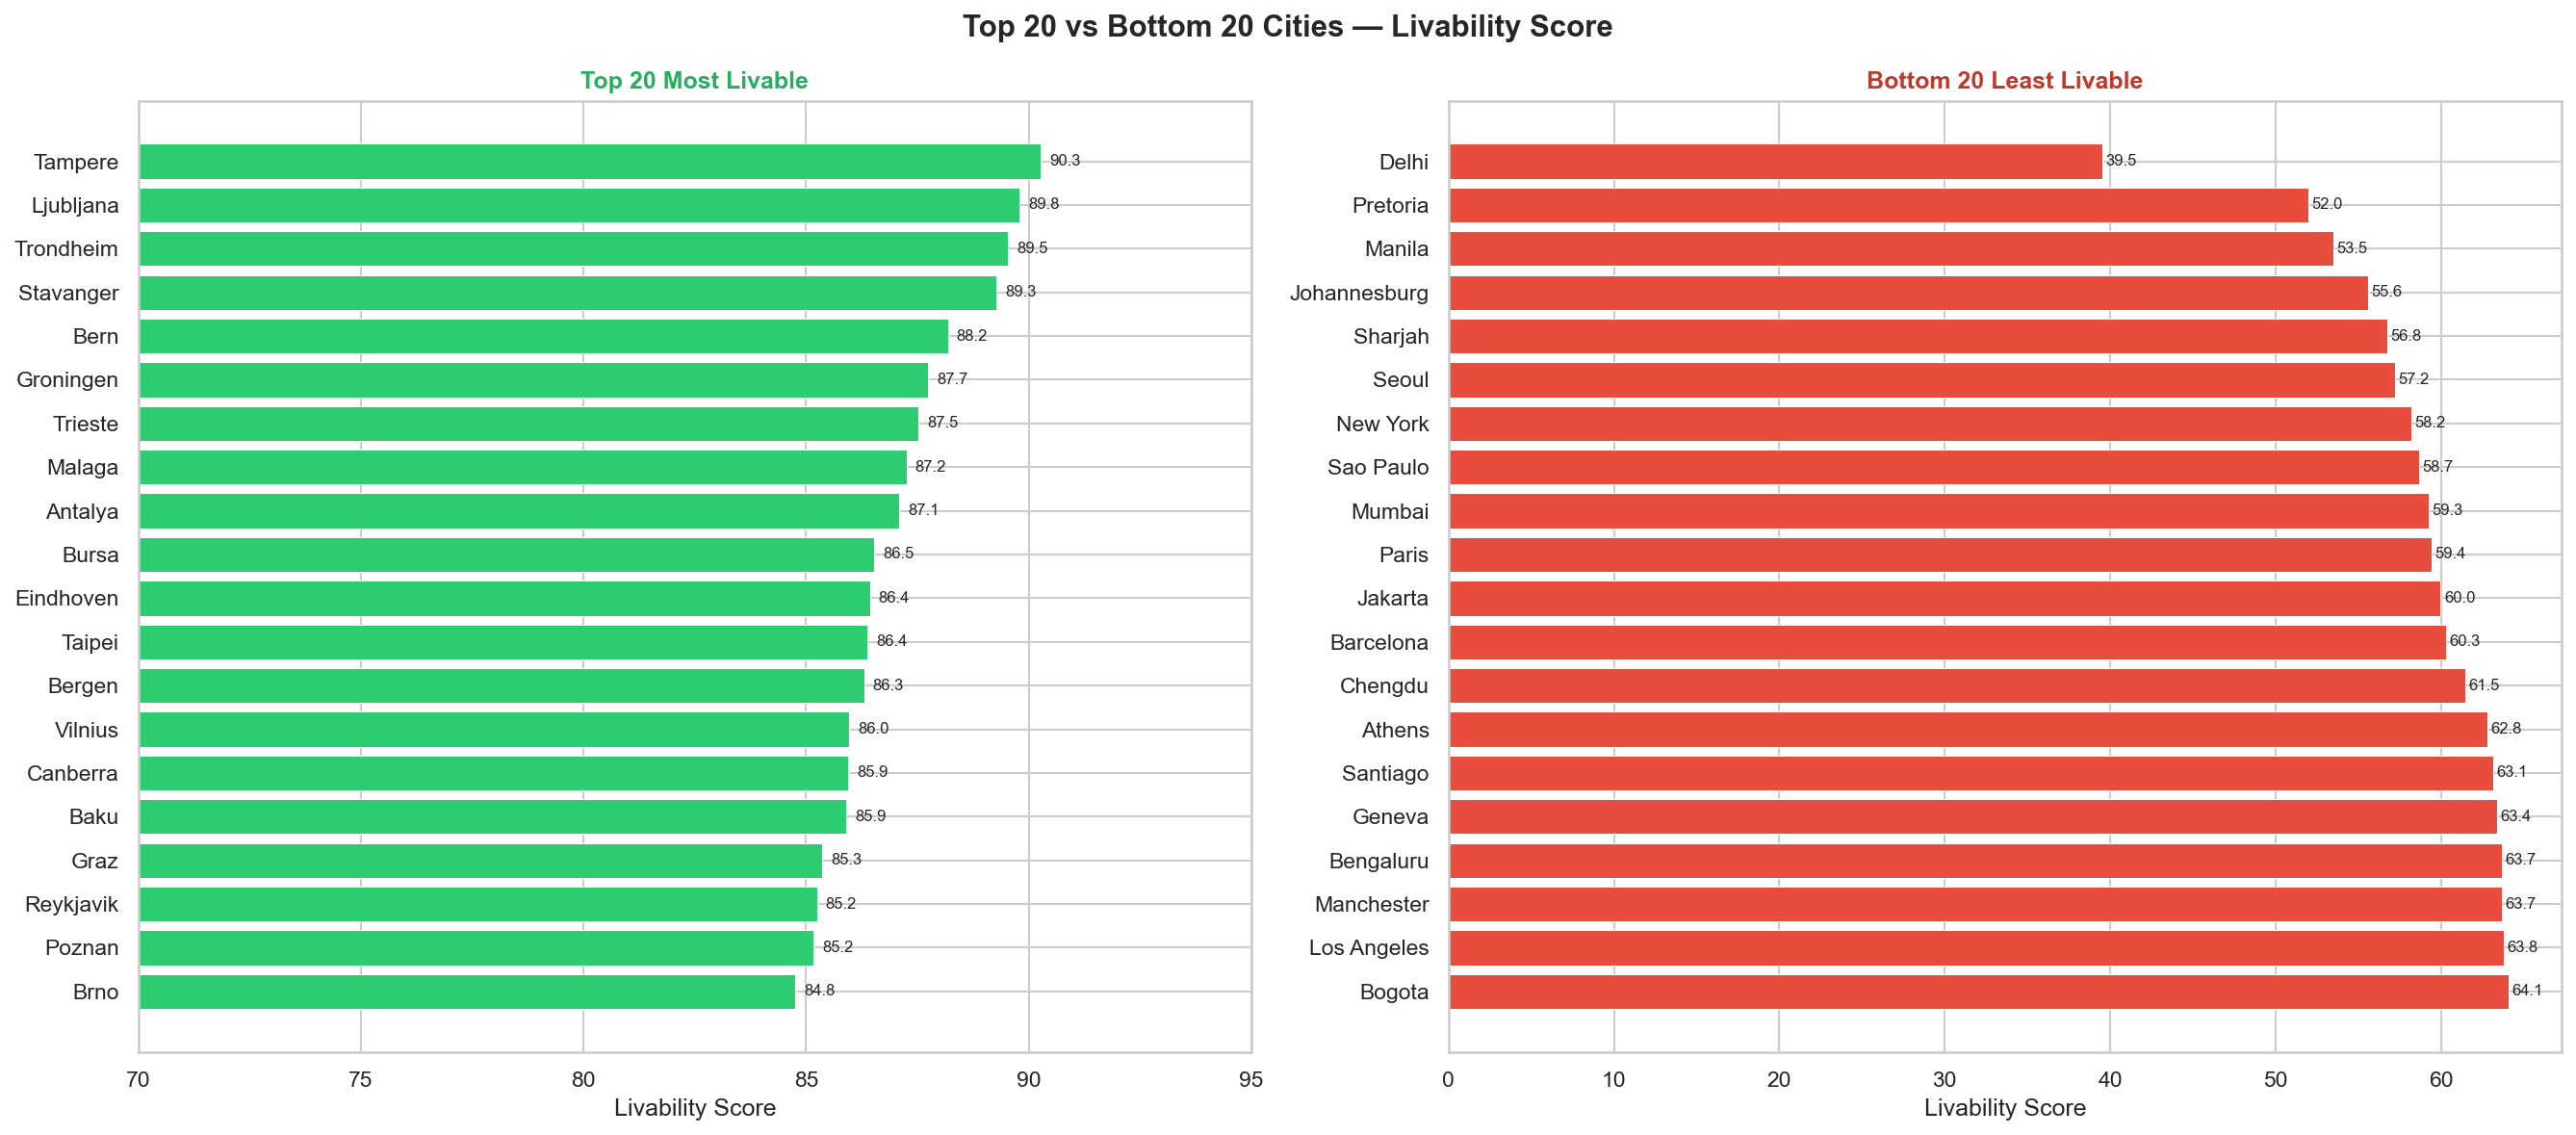

Saved → 03_top_bottom_20.png


In [4]:
top20    = df.nlargest(20,  'livability_score_absolute').sort_values('livability_score_absolute')
bottom20 = df.nsmallest(20, 'livability_score_absolute').sort_values('livability_score_absolute', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Top 20 vs Bottom 20 Cities — Livability Score", 
             fontsize=15, fontweight='bold')

# Top 20
bars = axes[0].barh(top20['city'].str.title(), top20['livability_score_absolute'],
                    color='#2ECC71', edgecolor='white', linewidth=0.5)
axes[0].set_title('Top 20 Most Livable', fontweight='bold', color='#27AE60')
axes[0].set_xlabel('Livability Score')
axes[0].set_xlim(70, 95)
for bar, score in zip(bars, top20['livability_score_absolute']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{score:.1f}', va='center', fontsize=8)

# Bottom 20
bars2 = axes[1].barh(bottom20['city'].str.title(), bottom20['livability_score_absolute'],
                     color='#E74C3C', edgecolor='white', linewidth=0.5)
axes[1].set_title('Bottom 20 Least Livable', fontweight='bold', color='#C0392B')
axes[1].set_xlabel('Livability Score')
for bar, score in zip(bars2, bottom20['livability_score_absolute']):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{score:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS, "03_top_bottom_20.png"), bbox_inches='tight')
plt.show()
print("Saved → 03_top_bottom_20.png")

# 5. AQI vs Safety Scatter

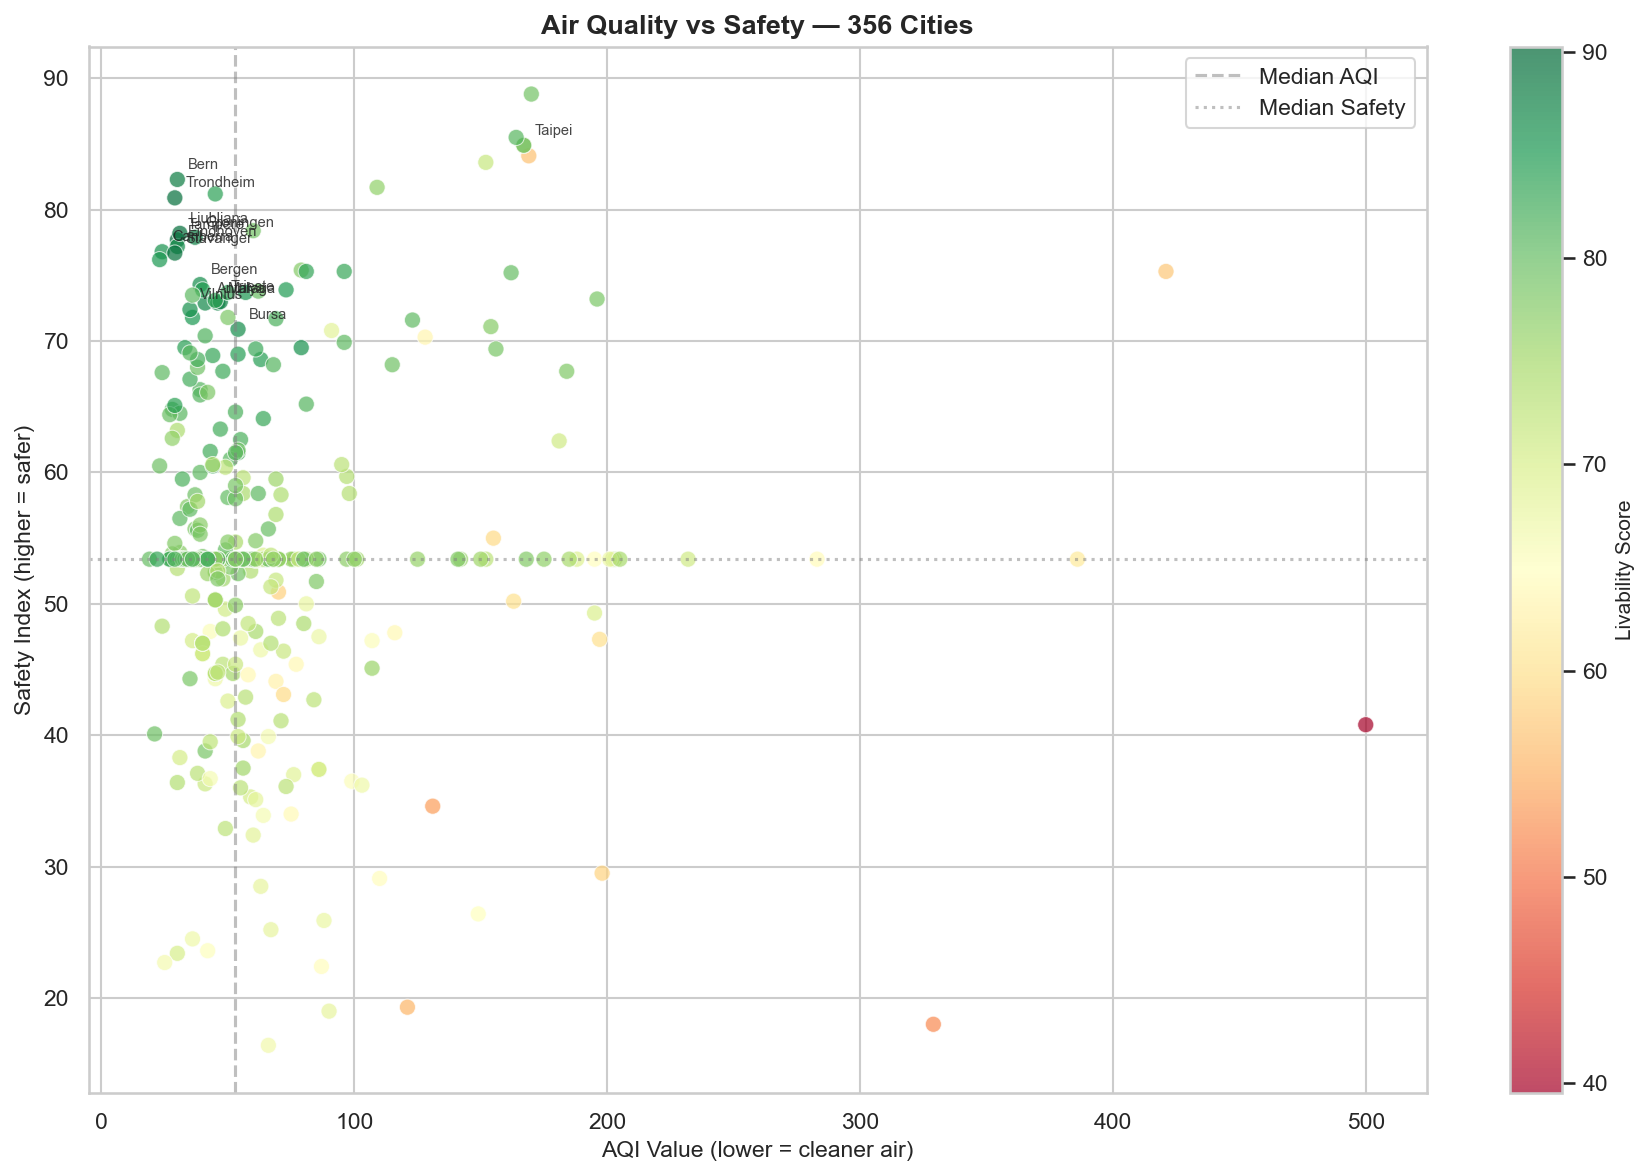

Saved → 04_aqi_vs_safety.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['aqi_value'], df['safety_index'],
                     c=df['livability_score_absolute'],
                     cmap='RdYlGn', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Livability Score', fontsize=10)

# label top 15 cities
top15 = df.nlargest(15, 'livability_score_absolute')
for _, row in top15.iterrows():
    ax.annotate(row['city'].title(),
                xy=(row['aqi_value'], row['safety_index']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, alpha=0.85)

ax.set_xlabel('AQI Value (lower = cleaner air)', fontsize=11)
ax.set_ylabel('Safety Index (higher = safer)', fontsize=11)
ax.set_title('Air Quality vs Safety — 356 Cities', fontsize=13, fontweight='bold')
ax.axvline(df['aqi_value'].median(), color='gray', linestyle='--', alpha=0.5, label='Median AQI')
ax.axhline(df['safety_index'].median(), color='gray', linestyle=':', alpha=0.5, label='Median Safety')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS, "04_aqi_vs_safety.png"), bbox_inches='tight')
plt.show()
print("Saved → 04_aqi_vs_safety.png")

# 6. Cost vs Livability Scatter

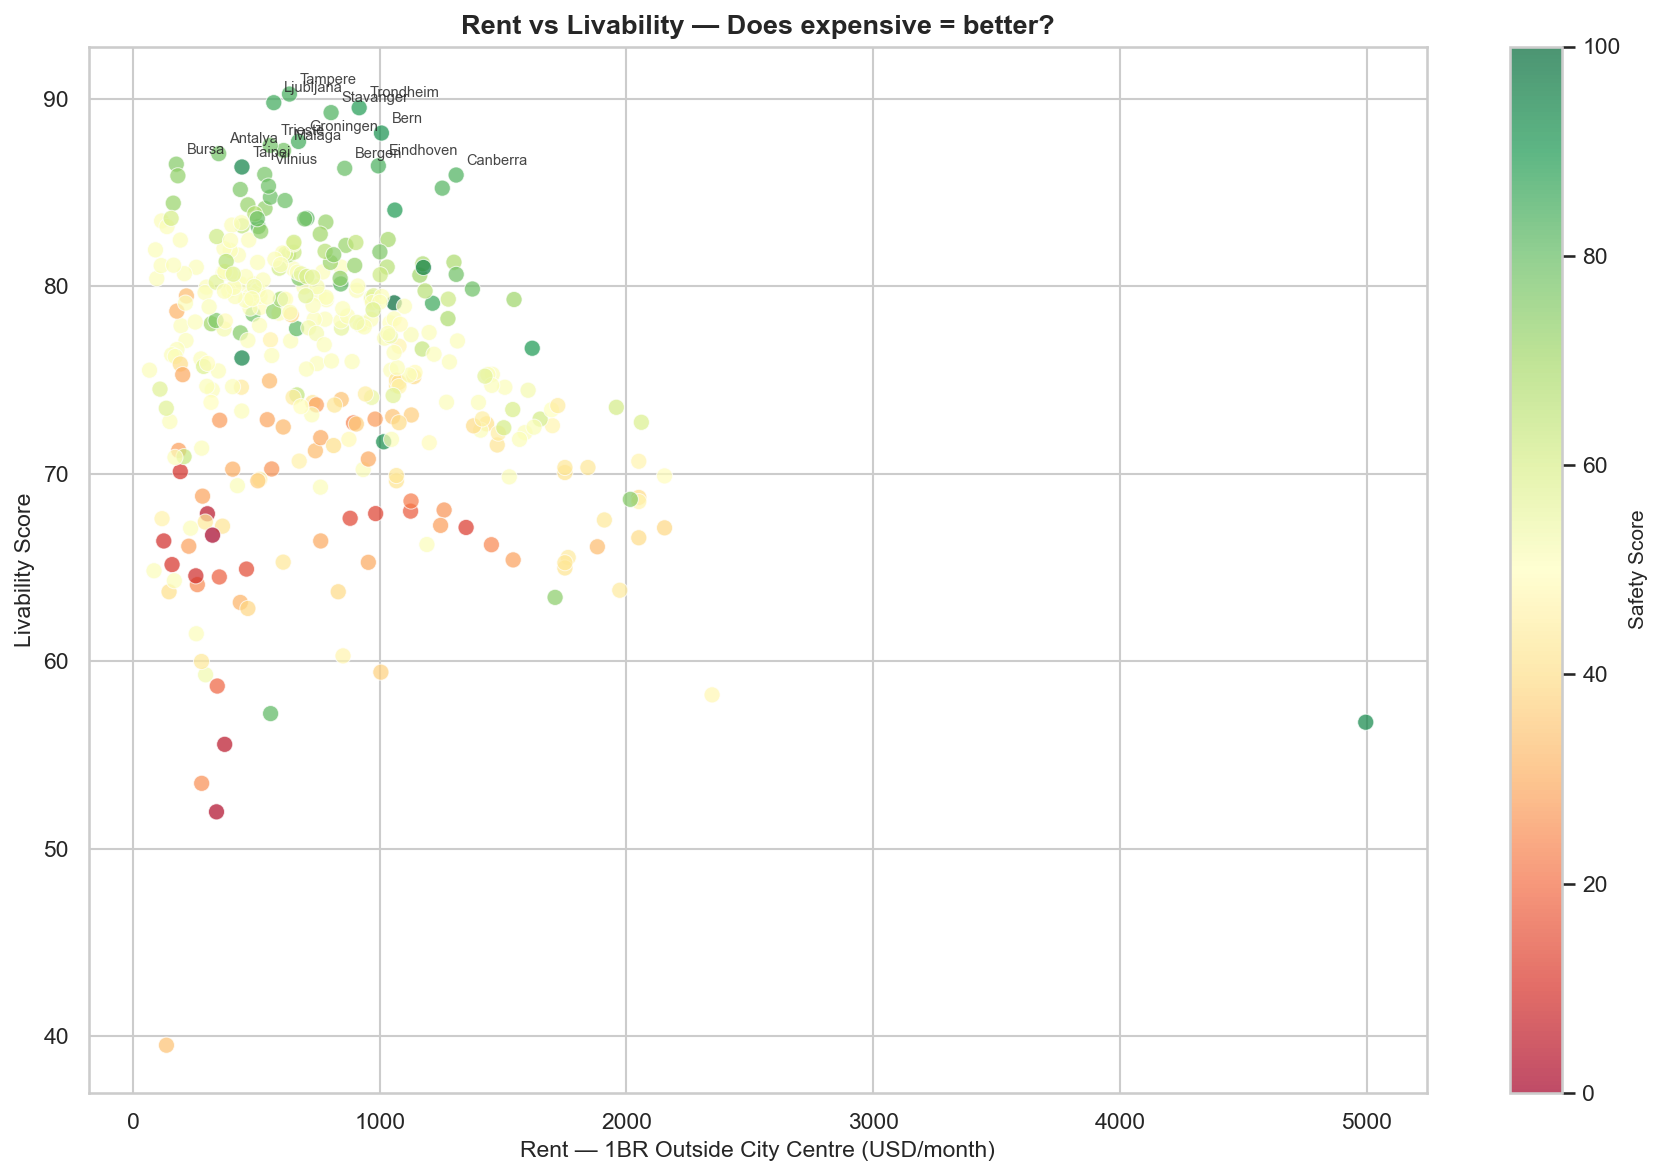

Saved → 05_rent_vs_livability.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['rent_1br_outside_usd'], df['livability_score_absolute'],
                     c=df['safety_score'],
                     cmap='RdYlGn', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Safety Score', fontsize=10)

top15 = df.nlargest(15, 'livability_score_absolute')
for _, row in top15.iterrows():
    ax.annotate(row['city'].title(),
                xy=(row['rent_1br_outside_usd'], row['livability_score_absolute']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, alpha=0.85)

ax.set_xlabel('Rent — 1BR Outside City Centre (USD/month)', fontsize=11)
ax.set_ylabel('Livability Score', fontsize=11)
ax.set_title('Rent vs Livability — Does expensive = better?', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS, "05_rent_vs_livability.png"), bbox_inches='tight')
plt.show()
print("Saved → 05_rent_vs_livability.png")

# 7. Average Score by Continent

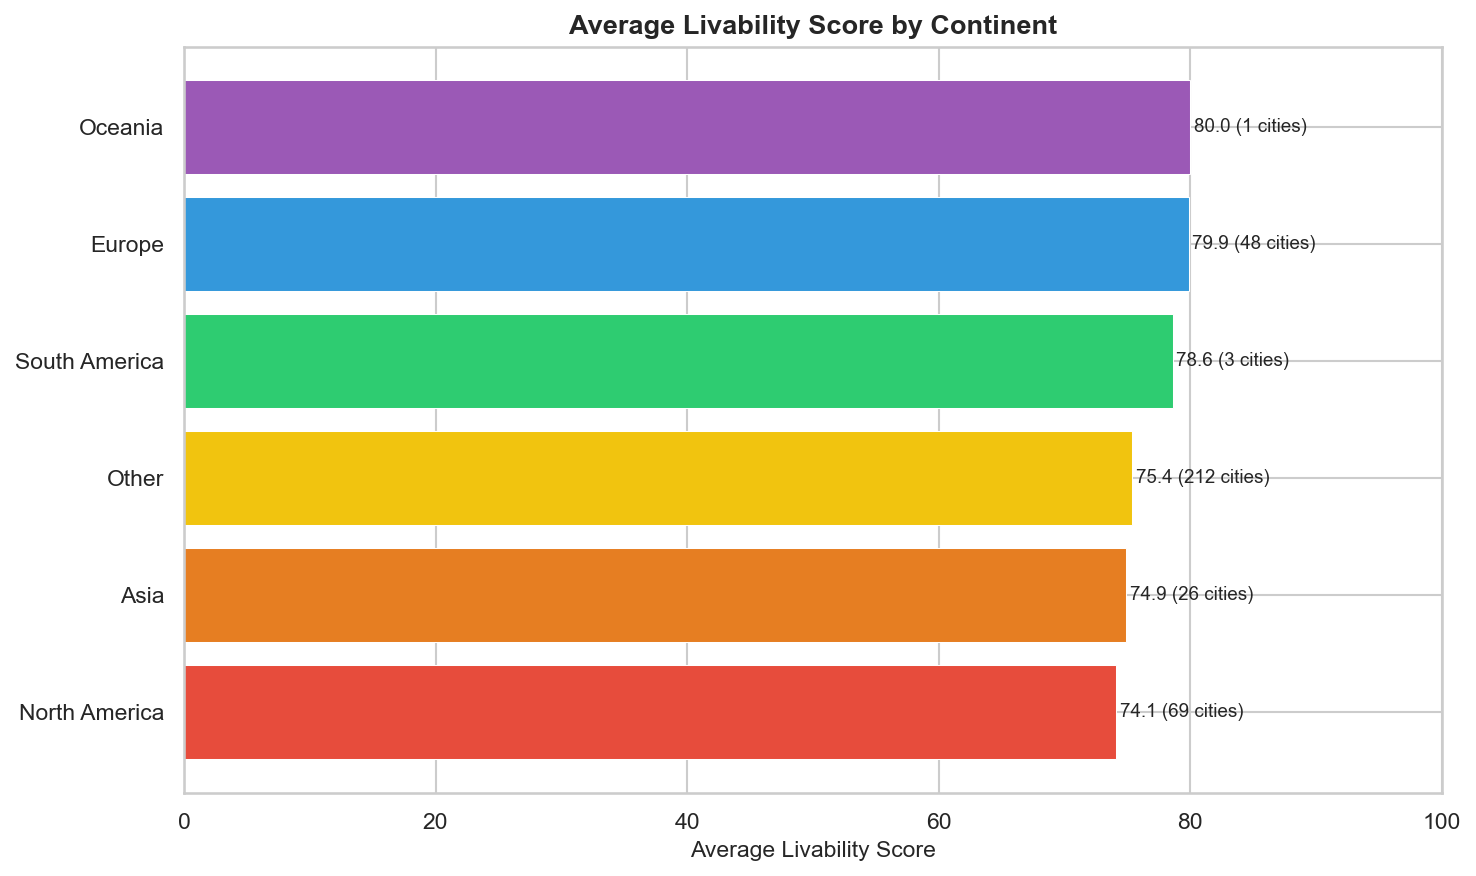

Saved → 06_score_by_continent.png


In [7]:
continent_map = {
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
    'Germany': 'Europe', 'France': 'Europe', 'Spain': 'Europe',
    'Italy': 'Europe', 'Netherlands': 'Europe', 'Norway': 'Europe',
    'Finland': 'Europe', 'Sweden': 'Europe', 'Denmark': 'Europe',
    'Austria': 'Europe', 'Switzerland': 'Europe', 'Poland': 'Europe',
    'Slovenia': 'Europe', 'Lithuania': 'Europe', 'Latvia': 'Europe',
    'Estonia': 'Europe', 'Czech Republic': 'Europe', 'Slovakia': 'Europe',
    'Hungary': 'Europe', 'Romania': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Serbia': 'Europe', 'Portugal': 'Europe',
    'Greece': 'Europe', 'Belgium': 'Europe', 'Ireland': 'Europe',
    'Iceland': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe',
    'United Kingdom': 'Europe', 'Russia': 'Europe',
    'United States of America': 'North America', 'Canada': 'North America',
    'Mexico': 'North America',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Colombia': 'South America', 'Chile': 'South America',
    'Peru': 'South America', 'Venezuela': 'South America',
    'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia',
    'South Korea': 'Asia', 'Thailand': 'Asia', 'Vietnam': 'Asia',
    'Indonesia': 'Asia', 'Malaysia': 'Asia', 'Philippines': 'Asia',
    'Singapore': 'Asia', 'Taiwan': 'Asia', 'Hong Kong': 'Asia',
    'Bangladesh': 'Asia', 'Pakistan': 'Asia', 'Nepal': 'Asia',
    'Qatar': 'Asia', 'UAE': 'Asia', 'Saudi Arabia': 'Asia',
    'Israel': 'Asia', 'Turkey': 'Asia', 'Iran': 'Asia',
    'South Africa': 'Africa', 'Nigeria': 'Africa', 'Kenya': 'Africa',
    'Egypt': 'Africa', 'Morocco': 'Africa', 'Ethiopia': 'Africa',
    'Ghana': 'Africa', 'Tanzania': 'Africa',
}

df['continent'] = df['country'].map(continent_map).fillna('Other')

continent_avg = df.groupby('continent')['livability_score_absolute'].agg(['mean','count'])\
                  .reset_index().sort_values('mean', ascending=True)
continent_avg.columns = ['continent', 'avg_score', 'city_count']

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6','#1ABC9C']
bars = ax.barh(continent_avg['continent'], continent_avg['avg_score'],
               color=colors[:len(continent_avg)], edgecolor='white', linewidth=0.5)

for bar, (_, row) in zip(bars, continent_avg.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{row['avg_score']:.1f} ({int(row['city_count'])} cities)",
            va='center', fontsize=9)

ax.set_xlabel('Average Livability Score', fontsize=11)
ax.set_title('Average Livability Score by Continent', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS, "06_score_by_continent.png"), bbox_inches='tight')
plt.show()
print("Saved → 06_score_by_continent.png")

# 8. Save EDA Summary Stats:

In [8]:
summary = {
    'total_cities': len(df),
    'top_city': df.loc[df['livability_score_absolute'].idxmax(), 'city'].title(),
    'top_score': df['livability_score_absolute'].max(),
    'bottom_city': df.loc[df['livability_score_absolute'].idxmin(), 'city'].title(),
    'bottom_score': df['livability_score_absolute'].min(),
    'avg_score': df['livability_score_absolute'].mean().round(2),
    'best_air_quality': df.loc[df['air_quality_score'].idxmax(), 'city'].title(),
    'safest_city': df.loc[df['safety_score'].idxmax(), 'city'].title(),
    'most_affordable': df.loc[df['cost_score_affordability'].idxmax(), 'city'].title(),
}

print("=" * 50)
print("EDA SUMMARY — PROJECT DAEDALUS")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:25s}: {v}")

pd.DataFrame([summary]).to_csv(
    os.path.join(CHARTS, "eda_summary.csv"), index=False)
print("\nAll 6 charts saved to outputs/charts/")

EDA SUMMARY — PROJECT DAEDALUS
  total_cities             : 359
  top_city                 : Tampere
  top_score                : 90.26
  bottom_city              : Delhi
  bottom_score             : 39.52
  avg_score                : 75.75
  best_air_quality         : Brasilia
  safest_city              : Abu Dhabi
  most_affordable          : Dunedin

All 6 charts saved to outputs/charts/
